In [2]:
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("NashvilleCarbonates.csv",index_col=0)

In [5]:
df.head()

,StratPosition,d13C,d18O,Al,Ca,Fe,Mg,Mn,Si
Ae,35.080,1.95,-4.66,1.49,297.16,1.52,2.22,0.34,8.61
Ad,34.745,1.82,-4.57,2.73,275.89,2.70,2.84,0.33,7.32
Ac,34.660,1.91,-4.77,4.26,328.11,3.13,3.12,0.40,9.65
Ab,34.555,0.93,-4.58,4.69,329.66,9.11,2.88,0.47,23.07
Aa,34.285,-0.34,-4.54,4.80,285.67,3.46,3.69,0.45,9.97


Text(0.5, 0, 'log10(Al concentration)')

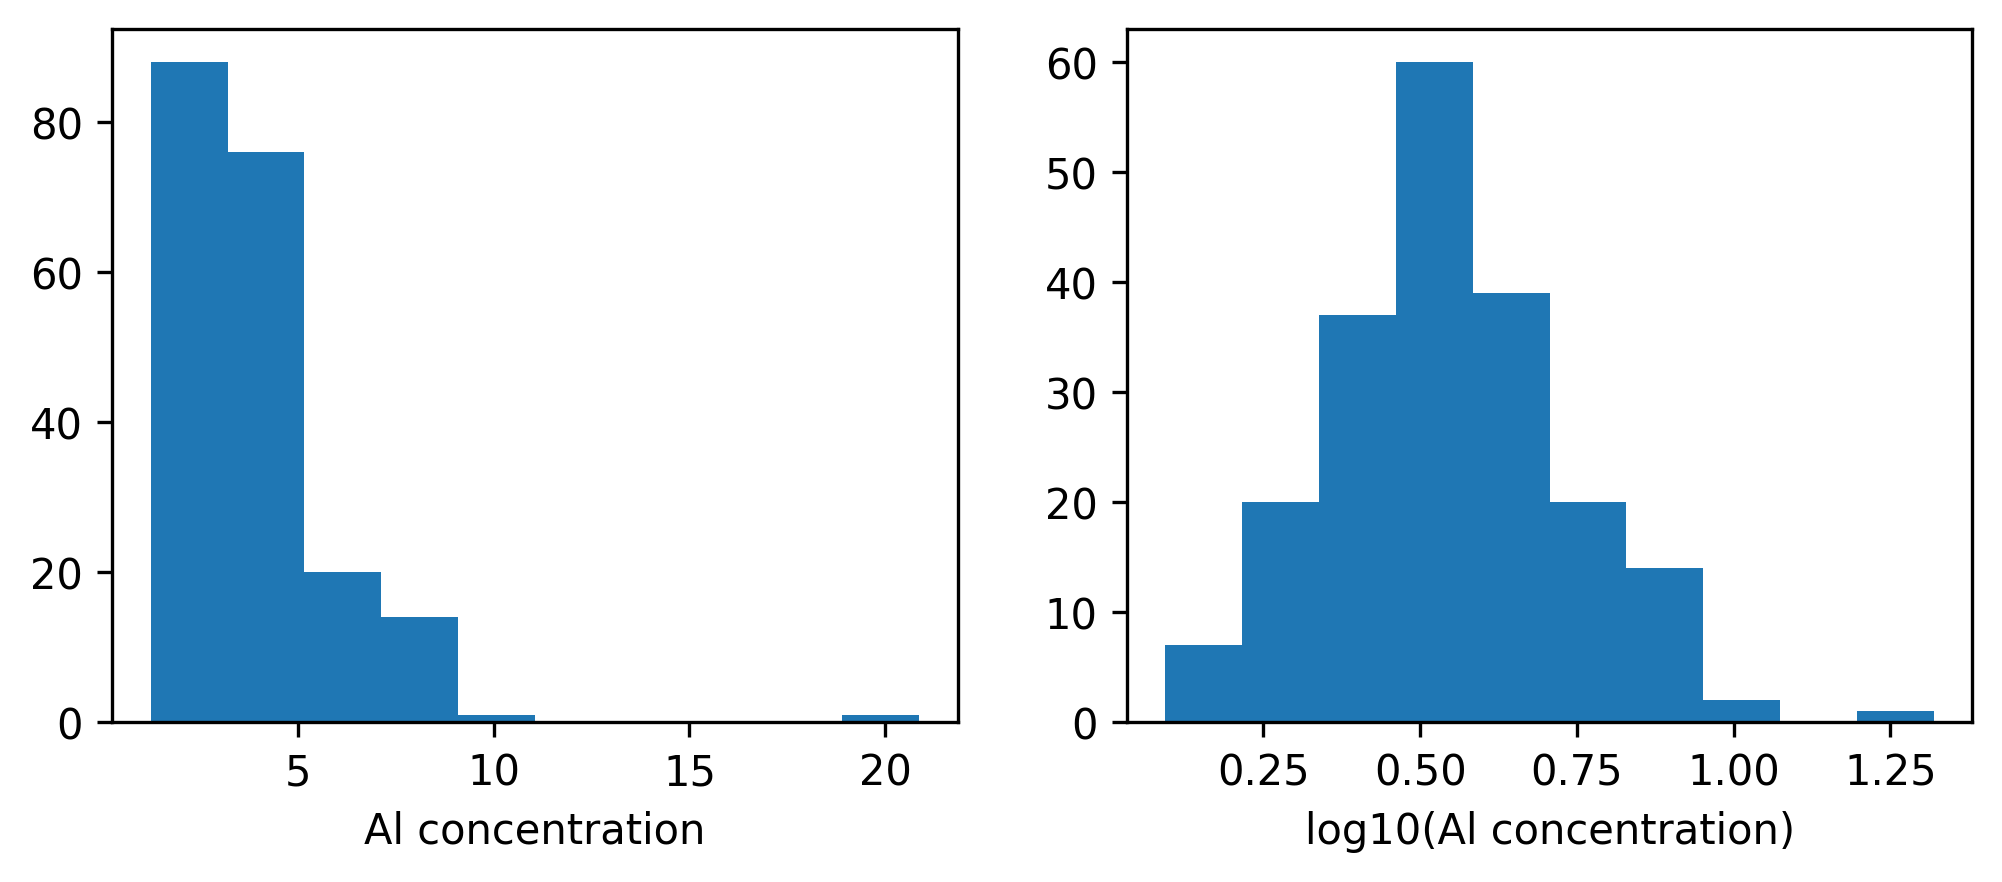

In [6]:
fig,ax=plt.subplots(1,2,figsize=[8,3],dpi=300)
ax[0].hist(df['Al'].values)
ax[0].set_xlabel("Al concentration")
ax[1].hist(np.log10(df['Al'].values))
ax[1].set_xlabel("log10(Al concentration)")

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [8]:
# 1) Load data
fn = 'NashvilleCarbonates.csv'
df = pd.read_csv(fn, index_col=0)

# 2) Select geochemical variables (R: geochem <- nashville[, 2:9])
# Columns are: StratPosition, d13C, d18O, Al, Ca, Fe, Mg, Mn, Si
geochem_cols = ['d13C','d18O','Al','Ca','Fe','Mg','Mn','Si']
geochem = df[geochem_cols].copy()

# 3) Log10-transform columns 3:8 in geochem (R uses 1-based indexing: Al..Si)
cols_to_log = ['Al','Ca','Fe','Mg','Mn','Si']
geochem[cols_to_log] = np.log10(geochem[cols_to_log])

geochem

,d13C,d18O,Al,Ca,Fe,Mg,Mn,Si
Ae,1.95,-4.66,0.173186,2.472990,0.181844,0.346353,-0.468521,0.935003
Ad,1.82,-4.57,0.436163,2.440736,0.431364,0.453318,-0.481486,0.864511
Ac,1.91,-4.77,0.629410,2.516019,0.495544,0.494155,-0.397940,0.984527
Ab,0.93,-4.58,0.671173,2.518066,0.959518,0.459392,-0.327902,1.363048
Aa,-0.34,-4.54,0.681241,2.455865,0.539076,0.567026,-0.346787,0.998695
...,...,...,...,...,...,...,...,...
H16,1.07,-3.91,0.886491,2.396635,0.891537,1.028164,-0.886057,1.106191
H17,1.28,-3.88,0.955688,2.390334,0.800029,0.911158,-0.958607,1.267406
H18,1.37,-3.97,0.635484,2.525796,0.591065,0.775246,-0.958607,0.894316
H19,0.49,-4.06,0.628389,2.476962,0.499687,0.612784,-1.154902,0.889302


In [9]:
# 4) Standardize (mean=0, std=1), equivalent to prcomp(..., scale.=TRUE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(geochem.values)


In [10]:
# 5) PCA
pca = PCA()  # keep all components
scores = pca.fit_transform(X_scaled)  # rotated scores (R: pca$x)

# Eigenvalues and variance explained
variance = pca.explained_variance_              # eigenvalues
var_ratio = pca.explained_variance_ratio_        # fraction
var_percent = np.round(var_ratio * 100, 2)

# Loadings (R: pca$rotation). In sklearn, eigenvectors are in components_.T
loadings = pd.DataFrame(
    pca.components_.T,
    index=geochem_cols,
    columns=[f'PC{i+1}' for i in range(len(geochem_cols))]
)

# Correlation loadings (variable–PC correlations) sometimes used for biplots
corr_loadings = loadings.values * np.sqrt(variance)
corr_loadings_df = pd.DataFrame(
    corr_loadings,
    index=geochem_cols,
    columns=[f'PC{i+1}' for i in range(len(geochem_cols))]
)

# Scores dataframe with sample IDs as index
scores_df = pd.DataFrame(
    scores,
    index=df.index,
    columns=[f'PC{i+1}' for i in range(scores.shape[1])]
)

In [11]:
round(loadings,2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
d13C,0.17,-0.23,0.64,-0.57,-0.42,0.06,0.06,0.00
d18O,-0.05,0.60,0.06,-0.26,0.24,0.55,0.45,-0.04
Al,0.50,0.29,0.03,0.18,-0.16,0.05,-0.15,0.76
Ca,-0.33,0.04,0.47,0.65,-0.26,-0.03,0.40,0.05
Fe,0.53,-0.09,-0.10,-0.01,0.16,-0.47,0.66,-0.12
Mg,0.06,0.55,0.44,0.00,0.27,-0.48,-0.36,-0.26
Mn,0.23,-0.42,0.39,0.21,0.67,0.33,-0.10,0.04
Si,0.51,0.09,-0.06,0.32,-0.36,0.35,-0.17,-0.58


In [12]:
round(corr_loadings_df,2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
d13C,0.29,-0.34,0.65,-0.54,-0.30,0.03,0.03,0.00
d18O,-0.08,0.88,0.06,-0.24,0.17,0.29,0.21,-0.01
Al,0.85,0.43,0.03,0.17,-0.12,0.02,-0.07,0.20
Ca,-0.57,0.06,0.49,0.61,-0.19,-0.02,0.19,0.01
Fe,0.90,-0.13,-0.10,-0.01,0.12,-0.25,0.31,-0.03
Mg,0.10,0.81,0.45,0.00,0.19,-0.25,-0.17,-0.07
Mn,0.40,-0.62,0.40,0.20,0.48,0.17,-0.05,0.01
Si,0.87,0.13,-0.06,0.30,-0.26,0.18,-0.08,-0.15


In [13]:
# 6) Save tabular outputs
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(variance))],
    'eigenvalue': variance,
    'variance_explained_%': var_percent,
    'cumulative_%': np.cumsum(var_percent)
})

variance_df.to_csv('pca_variance_explained.csv', index=False)
loadings.to_csv('pca_loadings_eigenvectors.csv')
corr_loadings_df.to_csv('pca_correlation_loadings.csv')
scores_df.to_csv('pca_scores.csv')

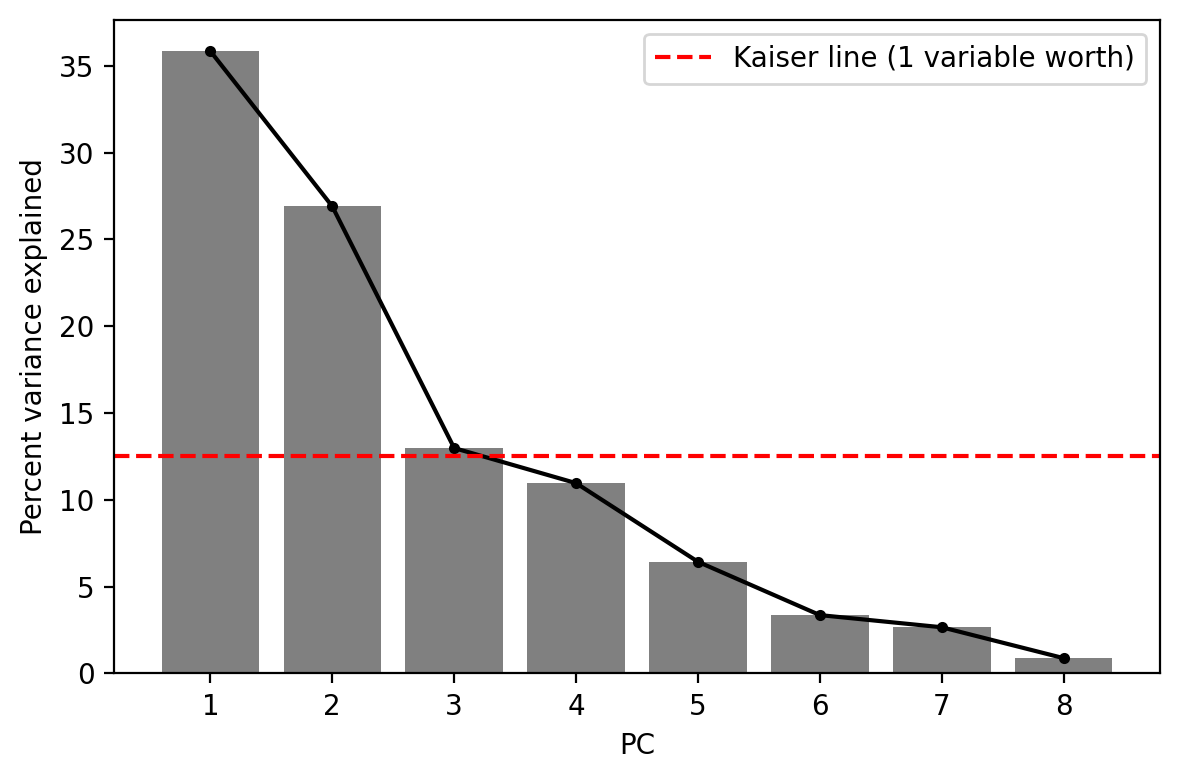

In [14]:
# 7) Scree plot (with Kaiser line = 1 variable's worth = 1/8 = 12.5% when standardized)
plt.figure(figsize=(6,4),dpi=200)
plt.bar(np.arange(1, len(var_percent)+1), var_percent, color='gray')
plt.plot(np.arange(1, len(var_percent)+1), var_percent, 'k.-')
plt.axhline(100/len(geochem_cols), color='red', linestyle='--', label='Kaiser line (1 variable worth)')
plt.xlabel('PC')
plt.ylabel('Percent variance explained')
plt.xticks(np.arange(1, len(var_percent)+1))
plt.legend()
plt.tight_layout()
# plt.savefig('scree_plot.png', dpi=150)
# plt.close()

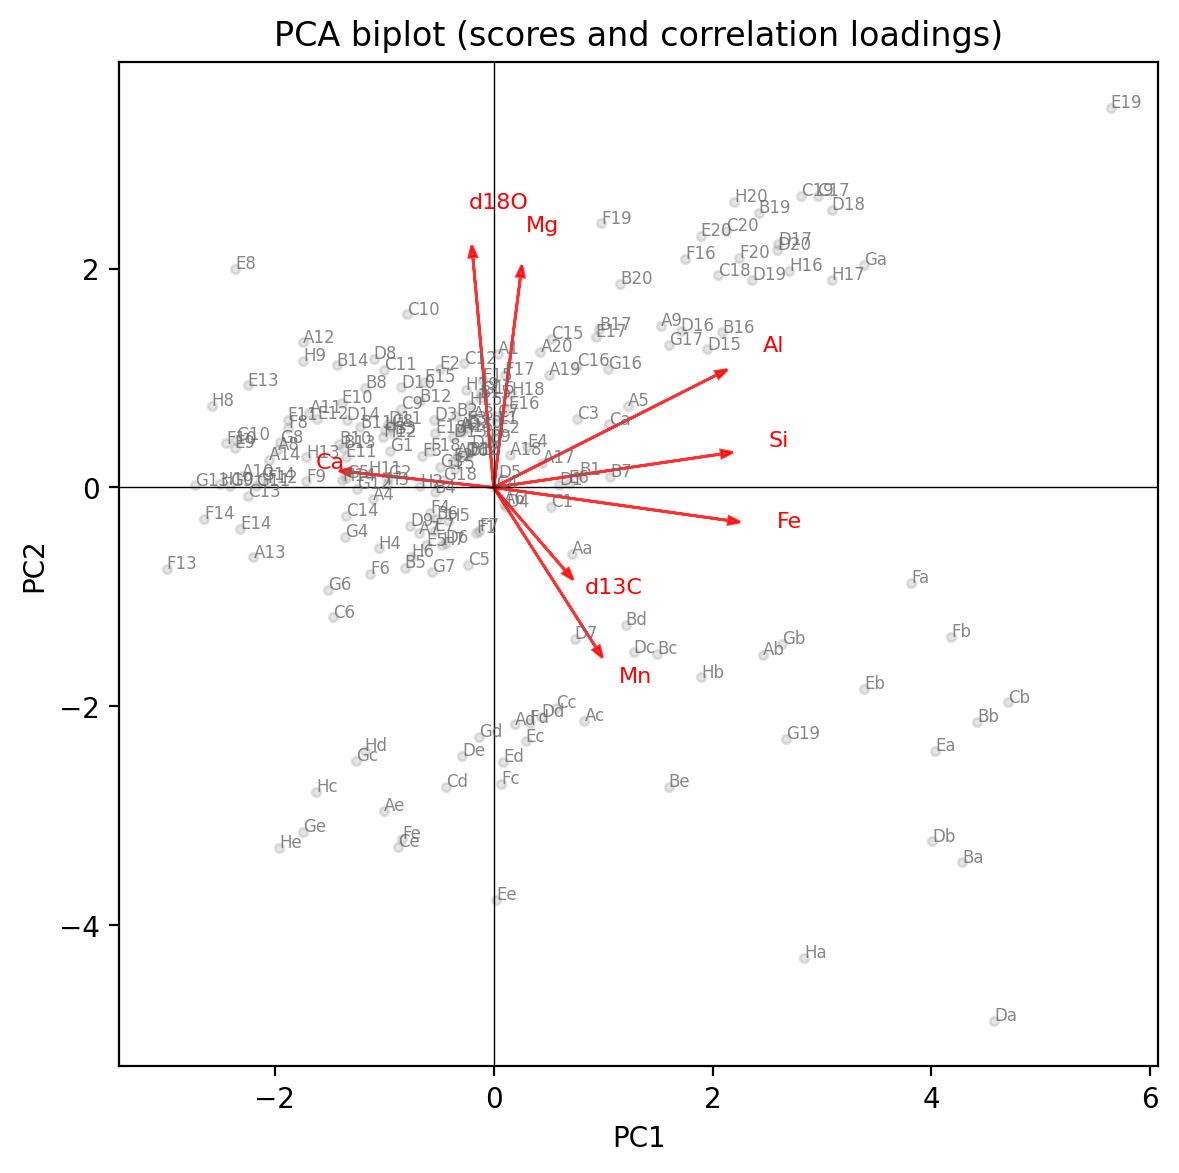

In [15]:
# 8) Biplot for PC1 vs PC2 using correlation loadings (nicer scaling)
fig, ax = plt.subplots(figsize=(6,6),dpi=200)
# scores
ax.scatter(scores_df['PC1'], scores_df['PC2'], s=10, c='gray', alpha=0.2)
# annotate points lightly (optional—dense labels can clutter)
for i, (x, y) in enumerate(zip(scores_df['PC1'], scores_df['PC2'])):
    # if i % 6 == 0:  # reduce clutter by labeling every ~6th point
    ax.text(x, y, scores_df.index[i], fontsize=6, color='dimgray', alpha=0.8)

# loadings as arrows
scale = 2.5  # adjust arrow length
for var in geochem_cols:
    ax.arrow(0, 0,
             corr_loadings_df.loc[var, 'PC1']*scale,
             corr_loadings_df.loc[var, 'PC2']*scale,
             color='red', alpha=0.8, head_width=0.07, length_includes_head=True)
    ax.text(corr_loadings_df.loc[var, 'PC1']*scale*1.15,
            corr_loadings_df.loc[var, 'PC2']*scale*1.15,
            var, color='red', fontsize=8)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA biplot (scores and correlation loadings)')
ax.set_aspect('equal', 'box')
plt.tight_layout()
# plt.savefig('biplot_pc1_pc2.png', dpi=150)
# plt.close()



In [16]:
# 9) Simple rules for significant PCs
kaiser_mask = variance > 1.0  # Kaiser criterion on standardized data
n95 = np.argmax(np.cumsum(var_percent) >= 95) + 1

kaiser_components = [f'PC{i+1}' for i, keep in enumerate(kaiser_mask) if keep]

# 10) (Optional) A lightweight permutation test for component significance
# Shuffles rows within each column (breaks correlation but preserves marginal distribution)
# Returns the 95th percentile of null eigenvalues for comparison

rng = np.random.default_rng(42)
n_perm = 250
null_eigs = np.zeros((n_perm, len(geochem_cols)))
for p in range(n_perm):
    X_perm = X_scaled.copy()
    for j in range(X_perm.shape[1]):
        rng.shuffle(X_perm[:, j])
    pca_null = PCA()
    pca_null.fit(X_perm)
    null_eigs[p, :] = pca_null.explained_variance_

null_thresholds = np.percentile(null_eigs, 95, axis=0)

perm_significant = variance > null_thresholds
perm_sig_components = [f'PC{i+1}' for i, keep in enumerate(perm_significant) if keep]

# Save a quick text summary
with open('pca_summary.txt', 'w') as f:
    f.write('Variance explained (%):\n')
    f.write(', '.join([str(v) for v in var_percent]) + '\n')
    f.write(f"Kaiser-kept PCs: {kaiser_components}\n")
    f.write(f"#PCs to reach 95% cum. variance: {n95}\n")
    f.write('Permutation 95th-percentile thresholds (eigenvalues):\n')
    f.write(', '.join([f"{x:.3f}" for x in null_thresholds]) + '\n')
    f.write(f"Permutation-significant PCs: {perm_sig_components}\n")

# Return a few key values to the notebook output
variance_df.head(), loadings.round(3).head(), corr_loadings_df.round(3).head(), scores_df.head(), kaiser_components, n95, perm_sig_components

(    PC  eigenvalue  variance_explained_%  cumulative_%
 0  PC1    2.881220                 35.84         35.84
 1  PC2    2.162857                 26.90         62.74
 2  PC3    1.043808                 12.98         75.72
 3  PC4    0.880825                 10.96         86.68
 4  PC5    0.517015                  6.43         93.11,
         PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
 d13C  0.171 -0.229  0.641 -0.571 -0.418  0.058  0.064  0.005
 d18O -0.047  0.601  0.058 -0.257  0.236  0.554  0.450 -0.038
 Al    0.503  0.293  0.033  0.184 -0.163  0.048 -0.147  0.759
 Ca   -0.333  0.042  0.475  0.652 -0.265 -0.033  0.404  0.050
 Fe    0.530 -0.086 -0.097 -0.011  0.164 -0.472  0.662 -0.118,
         PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
 d13C  0.290 -0.337  0.654 -0.536 -0.301  0.030  0.029  0.001
 d18O -0.080  0.884  0.060 -0.241  0.170  0.288  0.208 -0.010
 Al    0.854  0.431  0.034  0.173 -0.117  0.025 -0.068  0.202
 Ca   -0.566  0.061  0.485  0.612 -0.190 -